<a href="https://colab.research.google.com/github/shreyakiyoor/Keras/blob/master/CNN_Lesson_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy,binary_crossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import imagenet_utils

from sklearn.metrics import confusion_matrix

import glob
from google.colab import drive
import os
import random
import shutil

import matplotlib.pyplot as plt
import seaborn as sns


from io import BytesIO
from PIL import Image


import pandas as pd
import numpy as np
from tqdm import tqdm

In [5]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
def prepare_image(image_path):
  image_load = image.load_img(image_path,target_size = (224,224))
  image_arr = image.img_to_array(image_load)
  image_expand_dims = np.expand_dims(image_arr,axis = 0)
  return tf.keras.applications.mobilenet.preprocess_input(image_expand_dims)

In [7]:
mobile = tf.keras.applications.mobilenet.MobileNet()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
preprocess_image = prepare_image("/content/drive/MyDrive/Problems/CNN/peacock.jpg")
predicted_output = mobile.predict(preprocess_image)

results = tf.keras.applications.mobilenet.decode_predictions(predicted_output,top = 10)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n01806143', 'peacock', np.float32(0.9994879)),
  ('n01795545', 'black_grouse', np.float32(0.000103150705)),
  ('n01687978', 'agama', np.float32(9.082562e-05)),
  ('n01828970', 'bee_eater', np.float32(3.6052075e-05)),
  ('n02486261', 'patas', np.float32(3.3063152e-05)),
  ('n01798484', 'prairie_chicken', np.float32(2.4855834e-05)),
  ('n04604644', 'worm_fence', np.float32(1.9527251e-05)),
  ('n02017213', 'European_gallinule', np.float32(1.3833445e-05)),
  ('n01608432', 'kite', np.float32(1.1341077e-05)),
  ('n01806567', 'quail', np.float32(1.1223079e-05))]]

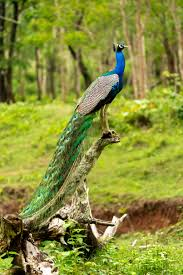

In [ ]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/peacock.jpg",width = 300,height = 200)

In [ ]:
preprocess_image = prepare_image("/content/drive/MyDrive/Problems/CNN/peacock1.jpg")
predicted_output = mobile.predict(preprocess_image)

results = tf.keras.applications.mobilenet.decode_predictions(predicted_output,top = 10)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


[[('n01806143', 'peacock', np.float32(0.9906069)),
  ('n02009229', 'little_blue_heron', np.float32(0.002222715)),
  ('n02002724', 'black_stork', np.float32(0.002130559)),
  ('n01843065', 'jacamar', np.float32(0.0011316285)),
  ('n01739381', 'vine_snake', np.float32(0.00088708254)),
  ('n02017213', 'European_gallinule', np.float32(0.0005834492)),
  ('n02526121', 'eel', np.float32(0.0003765609)),
  ('n12144580', 'corn', np.float32(0.00023345392)),
  ('n02018795', 'bustard', np.float32(0.00018603662)),
  ('n02165105', 'tiger_beetle', np.float32(0.00017186583))]]

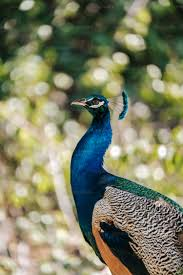

In [ ]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/peacock1.jpg",width = 300,height = 200)

In [ ]:
preprocess_image = prepare_image("/content/drive/MyDrive/Problems/CNN/MD.jpg")
predicted_output = mobile.predict(preprocess_image)

results = tf.keras.applications.mobilenet.decode_predictions(predicted_output,top = 10)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


[[('n04350905', 'suit', np.float32(0.12307803)),
  ('n04591157', 'Windsor_tie', np.float32(0.092996456)),
  ('n04479046', 'trench_coat', np.float32(0.08794078)),
  ('n03485407', 'hand-held_computer', np.float32(0.056950066)),
  ('n04418357', 'theater_curtain', np.float32(0.05282942)),
  ('n03942813', 'ping-pong_ball', np.float32(0.043323714)),
  ('n01440764', 'tench', np.float32(0.039644007)),
  ('n03630383', 'lab_coat', np.float32(0.037516583)),
  ('n04409515', 'tennis_ball', np.float32(0.026970087)),
  ('n03832673', 'notebook', np.float32(0.025068283))]]

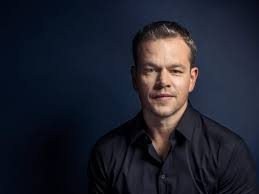

In [ ]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/MD.jpg",width = 300,height = 300)

In [ ]:
preprocess_image = prepare_image("/content/drive/MyDrive/Problems/CNN/pizza.jpg")
predicted_output = mobile.predict(preprocess_image)

results = tf.keras.applications.mobilenet.decode_predictions(predicted_output,top = 10)
results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


[[('n07873807', 'pizza', np.float32(0.99998987)),
  ('n07565083', 'menu', np.float32(2.2118518e-06)),
  ('n07579787', 'plate', np.float32(2.16405e-06)),
  ('n04597913', 'wooden_spoon', np.float32(8.376497e-07)),
  ('n01985128', 'crayfish', np.float32(4.946608e-07)),
  ('n03259280', 'Dutch_oven', np.float32(4.0918655e-07)),
  ('n07768694', 'pomegranate', np.float32(3.805968e-07)),
  ('n07875152', 'potpie', np.float32(3.3951434e-07)),
  ('n04263257', 'soup_bowl', np.float32(3.3071746e-07)),
  ('n07717556', 'butternut_squash', np.float32(3.2270168e-07))]]

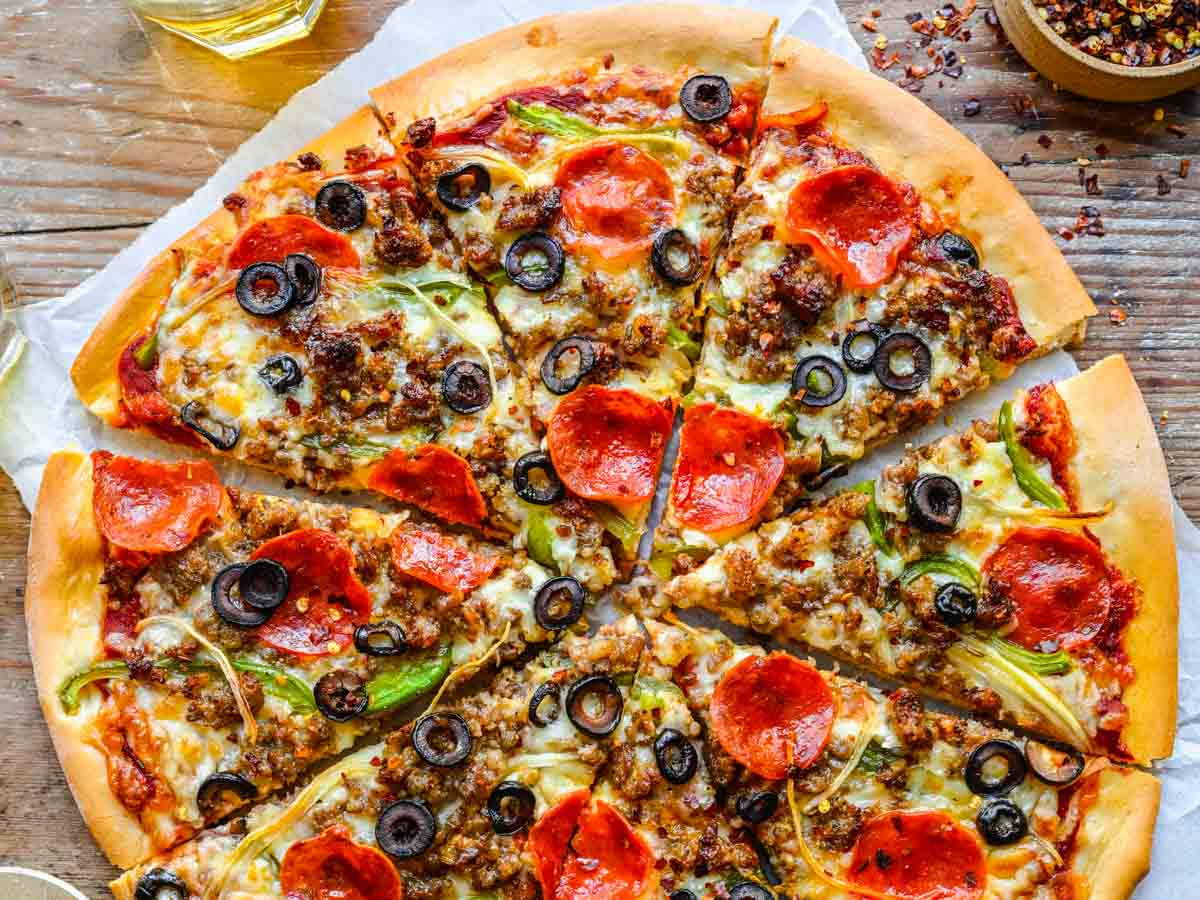

In [ ]:
Image("/content/drive/MyDrive/Problems/CNN/pizza.jpg",width = 300,height = 300)